In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('..')

from agents import OrchestratorAgent

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
data_path = "../data/raw/agentic_ai_performance_dataset_20250622.csv"

df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (5000, 26)

Columns: ['agent_id', 'agent_type', 'model_architecture', 'deployment_environment', 'task_category', 'task_complexity', 'autonomy_level', 'success_rate', 'accuracy_score', 'efficiency_score', 'execution_time_seconds', 'response_latency_ms', 'memory_usage_mb', 'cpu_usage_percent', 'cost_per_task_cents', 'human_intervention_required', 'error_recovery_rate', 'multimodal_capability', 'edge_compatibility', 'privacy_compliance_score', 'bias_detection_score', 'timestamp', 'data_quality_score', 'performance_index', 'cost_efficiency_ratio', 'autonomous_capability_score']

First 5 rows:


,agent_id,agent_type,model_architecture,deployment_environment,task_category,task_complexity,autonomy_level,success_rate,accuracy_score,efficiency_score,...,error_recovery_rate,multimodal_capability,edge_compatibility,privacy_compliance_score,bias_detection_score,timestamp,data_quality_score,performance_index,cost_efficiency_ratio,autonomous_capability_score
0,AG_01012,Project Manager,PaLM-2,Server,Text Processing,5,3,0.4788,0.6455,0.6573,...,0.4999,False,False,0.9390,0.8061,2024-12-24 04:16:15,0.9510,0.58236,50.203448,64.993
1,AG_00758,Marketing Assistant,Mixtral-8x7B,Hybrid,Decision Making,6,5,0.4833,0.5660,0.5844,...,0.5580,False,False,0.8281,0.7816,2024-12-24 04:16:15,0.7822,0.53844,69.030769,89.060
2,AG_00966,QA Tester,Mixtral-8x7B,Server,Communication,2,4,0.8116,0.8395,0.7650,...,0.9196,False,False,0.7450,0.8214,2024-12-24 04:16:15,0.7621,0.80599,127.934921,124.372
3,AG_00480,Code Assistant,CodeT5+,Hybrid,Creative Writing,8,6,0.3574,0.4888,0.4742,...,0.3809,True,False,0.9653,0.8684,2024-12-24 04:16:15,0.8117,0.43186,21.066341,86.663
4,AG_01050,QA Tester,Falcon-180B,Edge,Planning & Scheduling,3,4,0.5706,0.7137,0.7209,...,0.6717,False,True,0.9042,0.8417,2024-12-24 04:16:15,0.7762,0.65862,57.271304,87.019


In [3]:
print("=== Dataset Information ===\n")
df.info()

print("\n=== Statistical Summary ===\n")
df.describe()

=== Dataset Information ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   agent_id                     5000 non-null   object 
 1   agent_type                   5000 non-null   object 
 2   model_architecture           5000 non-null   object 
 3   deployment_environment       5000 non-null   object 
 4   task_category                5000 non-null   object 
 5   task_complexity              5000 non-null   int64  
 6   autonomy_level               5000 non-null   int64  
 7   success_rate                 5000 non-null   float64
 8   accuracy_score               5000 non-null   float64
 9   efficiency_score             5000 non-null   float64
 10  execution_time_seconds       5000 non-null   float64
 11  response_latency_ms          5000 non-null   float64
 12  memory_usage_mb              5000 non-null   fl

,task_complexity,autonomy_level,success_rate,accuracy_score,efficiency_score,execution_time_seconds,response_latency_ms,memory_usage_mb,cpu_usage_percent,cost_per_task_cents,error_recovery_rate,privacy_compliance_score,bias_detection_score,data_quality_score,performance_index,cost_efficiency_ratio,autonomous_capability_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.083000,6.030600,0.490683,0.573375,0.588884,46.224444,899.599622,404.438560,68.956920,0.019453,0.565884,0.841938,0.774397,0.863688,0.544951,34.321394,102.345902
std,2.143789,2.403085,0.158827,0.127175,0.115969,25.997988,803.829179,111.743654,19.827232,0.009245,0.164149,0.081324,0.101954,0.066905,0.132550,21.864002,16.806164
min,2.000000,1.000000,0.300000,0.400000,0.300000,1.000000,100.010000,112.900000,10.900000,0.002700,0.300100,0.700000,0.600200,0.750000,0.330000,5.951597,56.284000
25%,4.000000,4.000000,0.338975,0.465475,0.501975,26.657500,338.532500,322.200000,54.600000,0.012400,0.426650,0.772000,0.685275,0.806400,0.428152,18.107412,89.828250
50%,6.000000,6.000000,0.470050,0.565950,0.588950,40.320000,637.680000,402.700000,68.500000,0.017500,0.547300,0.842200,0.773800,0.862450,0.536100,28.916278,102.633000
75%,8.000000,8.000000,0.613350,0.667925,0.674700,60.182500,1202.357500,488.325000,83.500000,0.024500,0.690025,0.913425,0.864325,0.922200,0.647397,45.149029,116.005000
max,10.000000,10.000000,0.976500,0.959600,0.885500,157.150000,5478.150000,686.600000,133.600000,0.058500,0.950000,0.979900,0.950000,0.979900,0.887470,219.327027,147.694000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✓ No missing values found!")

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

✓ No missing values found!


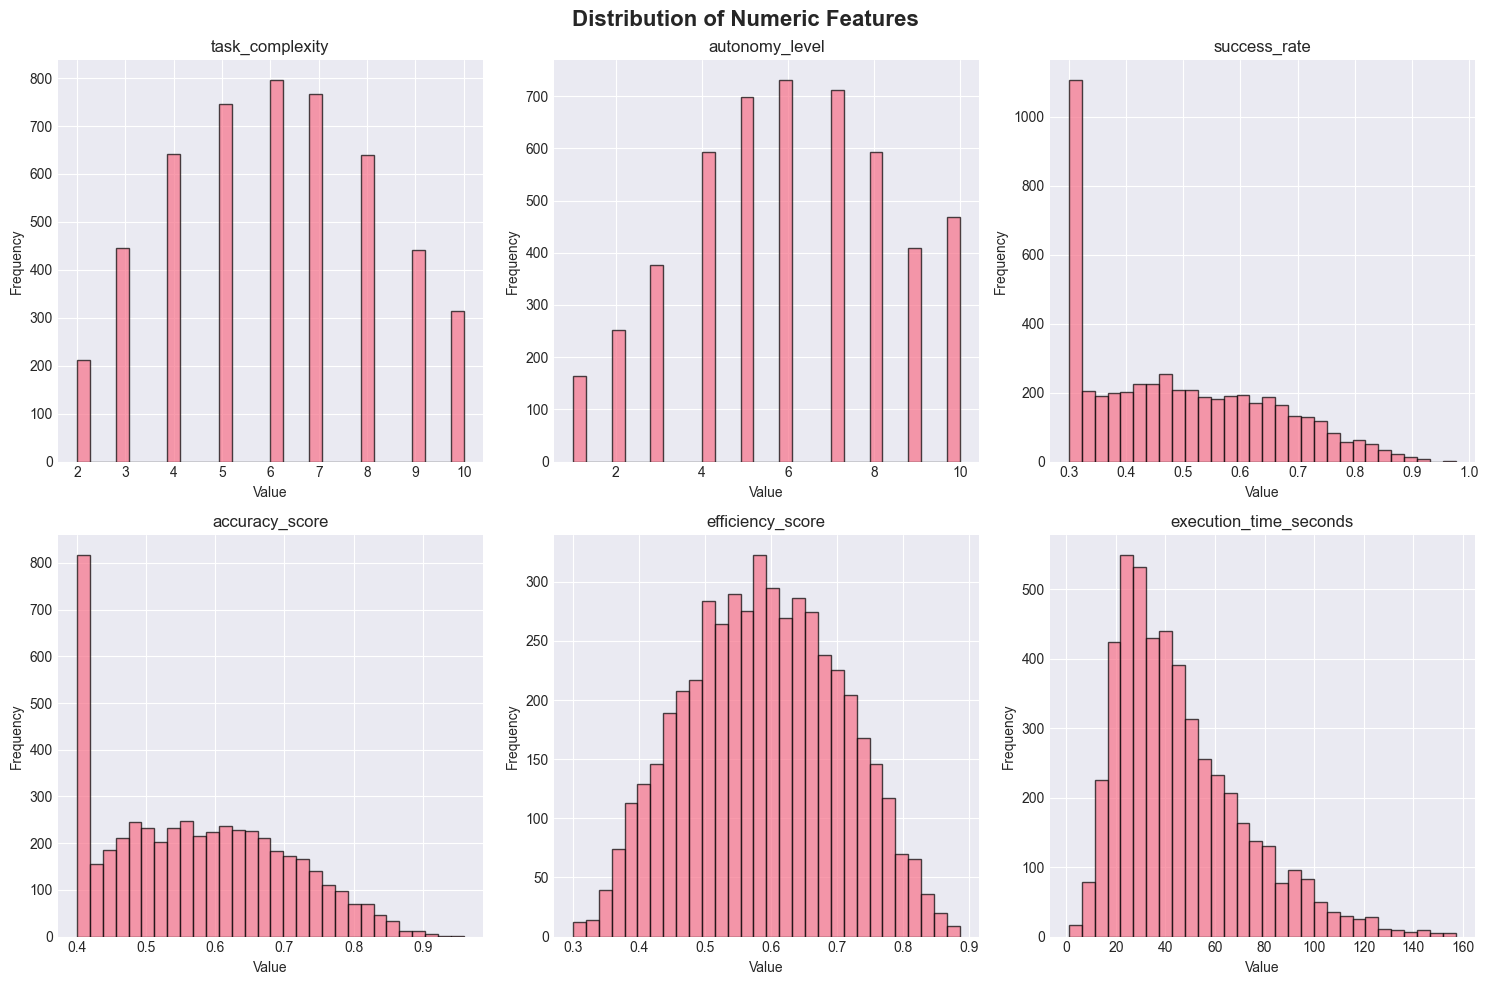

In [5]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(numeric_cols[:6]):
    row = idx // 3
    col_idx = idx % 3
    
    axes[row, col_idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_xlabel('Value')
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

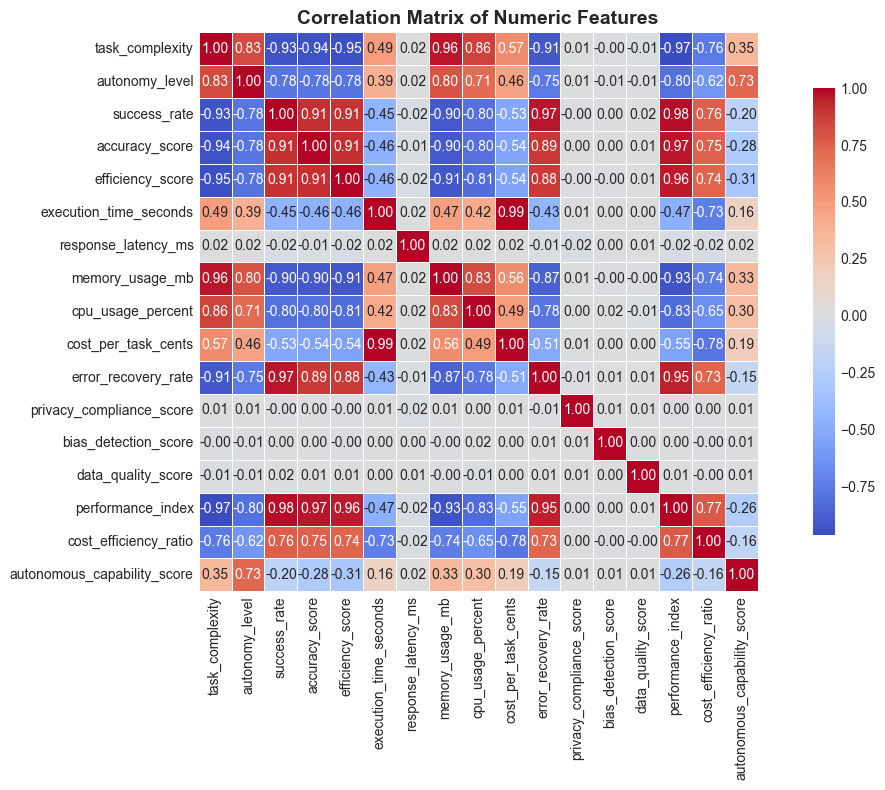

In [6]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
orchestrator = OrchestratorAgent()

results = orchestrator.run_pipeline(data_path)

print("\n=== Pipeline Results ===")
print(f"Status: {results['status']}")
print(f"\nMetrics:")
for key, value in results['metrics'].items():
    print(f"  {key}: {value}")

[2025-10-15 12:26:15] ============================================================
[2025-10-15 12:26:15] STARTING AI AGENTS PIPELINE
[2025-10-15 12:26:15] ============================================================
[2025-10-15 12:26:15] Loading data from: ../data/raw/agentic_ai_performance_dataset_20250622.csv
[2025-10-15 12:26:15] ✓ Data loaded: 5000 rows, 26 columns
[2025-10-15 12:26:15] Starting data processing...
[2025-10-15 12:26:15] Applying default processing (removing nulls)
[2025-10-15 12:26:15] ✓ Data processed with default method
[2025-10-15 12:26:15] Processing completed in 0.00 seconds
[2025-10-15 12:26:15] Starting model training...
[2025-10-15 12:26:15] Generating basic statistics
[2025-10-15 12:26:15] ✓ Basic analysis completed (no model training)
[2025-10-15 12:26:15] Training completed in 0.02 seconds
[2025-10-15 12:26:15] ============================================================
[2025-10-15 12:26:15] ✓ PIPELINE COMPLETED SUCCESSFULLY
[2025-10-15 12:26:15] Total t

In [8]:
charts, report = orchestrator.visualize_results(df, results)

print("✓ Visualizations generated")
print(f"\nCharts created:")
for name, path in charts.items():
    print(f"  - {name}: {path}")

print(f"\n✓ HTML Report: {report}")

[2025-10-15 12:26:17] Generating visualizations...
[2025-10-15 12:26:19] ✓ Charts generated
[2025-10-15 12:26:19] ✓ HTML report: results\report.html
✓ Visualizations generated

Charts created:
  - Data Overview: results/figures\data_overview.png
  - Pipeline Metrics: results/figures\pipeline_metrics.png
  - Processing Time: results/figures\processing_time.png

✓ HTML Report: results\report.html


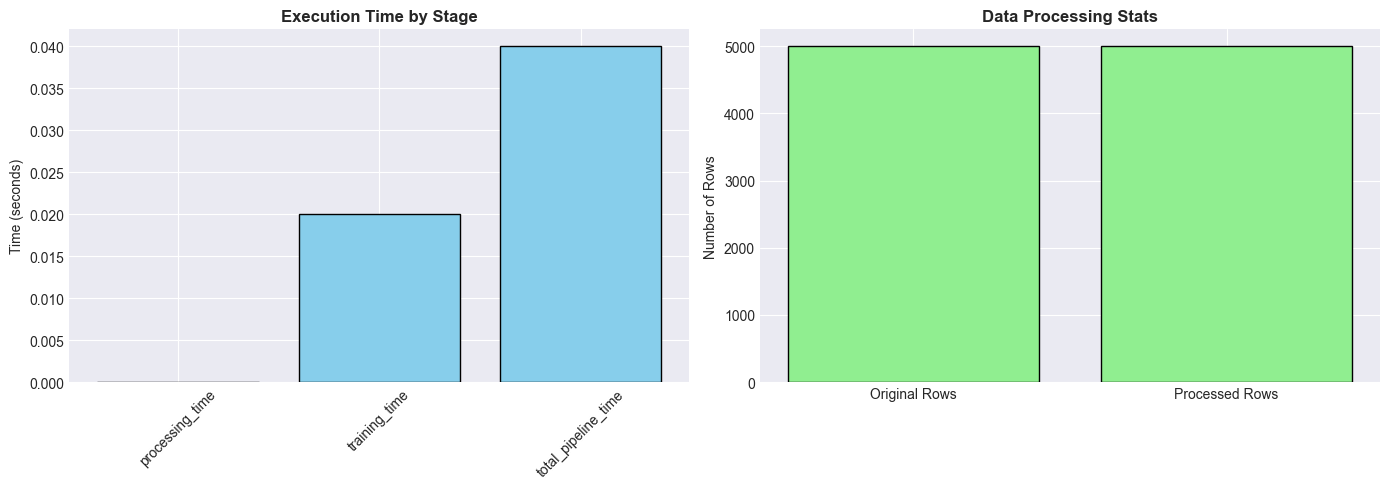


✓ Total Pipeline Time: 0.04s
✓ Processing Efficiency: 100.0%


In [9]:
metrics = results['metrics']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_metrics = {k: v for k, v in metrics.items() if 'time' in k}
axes[0].bar(time_metrics.keys(), time_metrics.values(), color='skyblue', edgecolor='black')
axes[0].set_title('Execution Time by Stage', fontweight='bold')
axes[0].set_ylabel('Time (seconds)')
axes[0].tick_params(axis='x', rotation=45)

data_metrics = {
    'Original Rows': metrics.get('original_rows', 0),
    'Processed Rows': metrics.get('processed_rows', 0)
}
axes[1].bar(data_metrics.keys(), data_metrics.values(), color='lightgreen', edgecolor='black')
axes[1].set_title('Data Processing Stats', fontweight='bold')
axes[1].set_ylabel('Number of Rows')

plt.tight_layout()
plt.show()

print(f"\n✓ Total Pipeline Time: {metrics.get('total_pipeline_time', 0)}s")
print(f"✓ Processing Efficiency: {metrics.get('processed_rows', 0) / metrics.get('original_rows', 1) * 100:.1f}%")

In [10]:
print("=== Analysis Complete ===\n")
print(f"✓ Dataset analyzed: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"✓ Pipeline executed successfully")
print(f"✓ Total execution time: {metrics.get('total_pipeline_time', 0)}s")
print(f"\n🎉 All analysis completed!")

=== Analysis Complete ===

✓ Dataset analyzed: 5000 rows, 26 columns
✓ Pipeline executed successfully
✓ Total execution time: 0.04s

🎉 All analysis completed!
